In [1]:
%load_ext autoreload
%autoreload 2
from stormvogel import show

from premise.sv_benchmarks.acas import build_acas_model

model = build_acas_model(radius_coarse=30, radius_max=2000, 
                         bearing_coarse=40, rel_heading_coarse=10, 
                         ego_speed_coarse=4, int_speed_coarse=4, timestep=2)

taking 192000 initial states


In [2]:
print(len(model.states))
# show(model, show_editor=True)

198380


1 0.0029405103134671684 -> State 172896 with labels ["{'init': False, 'radius': 1815.0, 'bearing': -3.141592653589793, 'rel_heading': 0.6283185307179586, 'ego_speed': 15.0, 'int_speed': 0.0, 'ACAState': State({'nmac': 150, 'timestep': 2, 'init': False, 'radius': CoarseValue(150, 2000, 30, 27), 'bearing': CoarseGaussianValue(0, -3.141592653589793, 3.141592653589793, 40, 0, 0.17453292519943295, 0.01), 'rel_heading': CoarseGaussianValue(6, -3.141592653589793, 3.141592653589793, 10, 0, 0.17453292519943295, 0.01), 'ego_speed': CoarseGaussianValue(0, 15, 75, 4, 0, 5, 0.01), 'int_speed': CoarseGaussianValue(0, 0, 75, 4, 0, 10, 0.01)})}"] and valuations {'init': False, 'radius': 1815.0, 'bearing': -3.141592653589793, 'rel_heading': 0.6283185307179586, 'ego_speed': 15.0, 'int_speed': 0.0, 'ACAState': State({'nmac': 150, 'timestep': 2, 'init': False, 'radius': CoarseValue(150, 2000, 30, 27), 'bearing': CoarseGaussianValue(0, -3.141592653589793, 3.141592653589793, 40, 0, 0.17453292519943295, 0.01

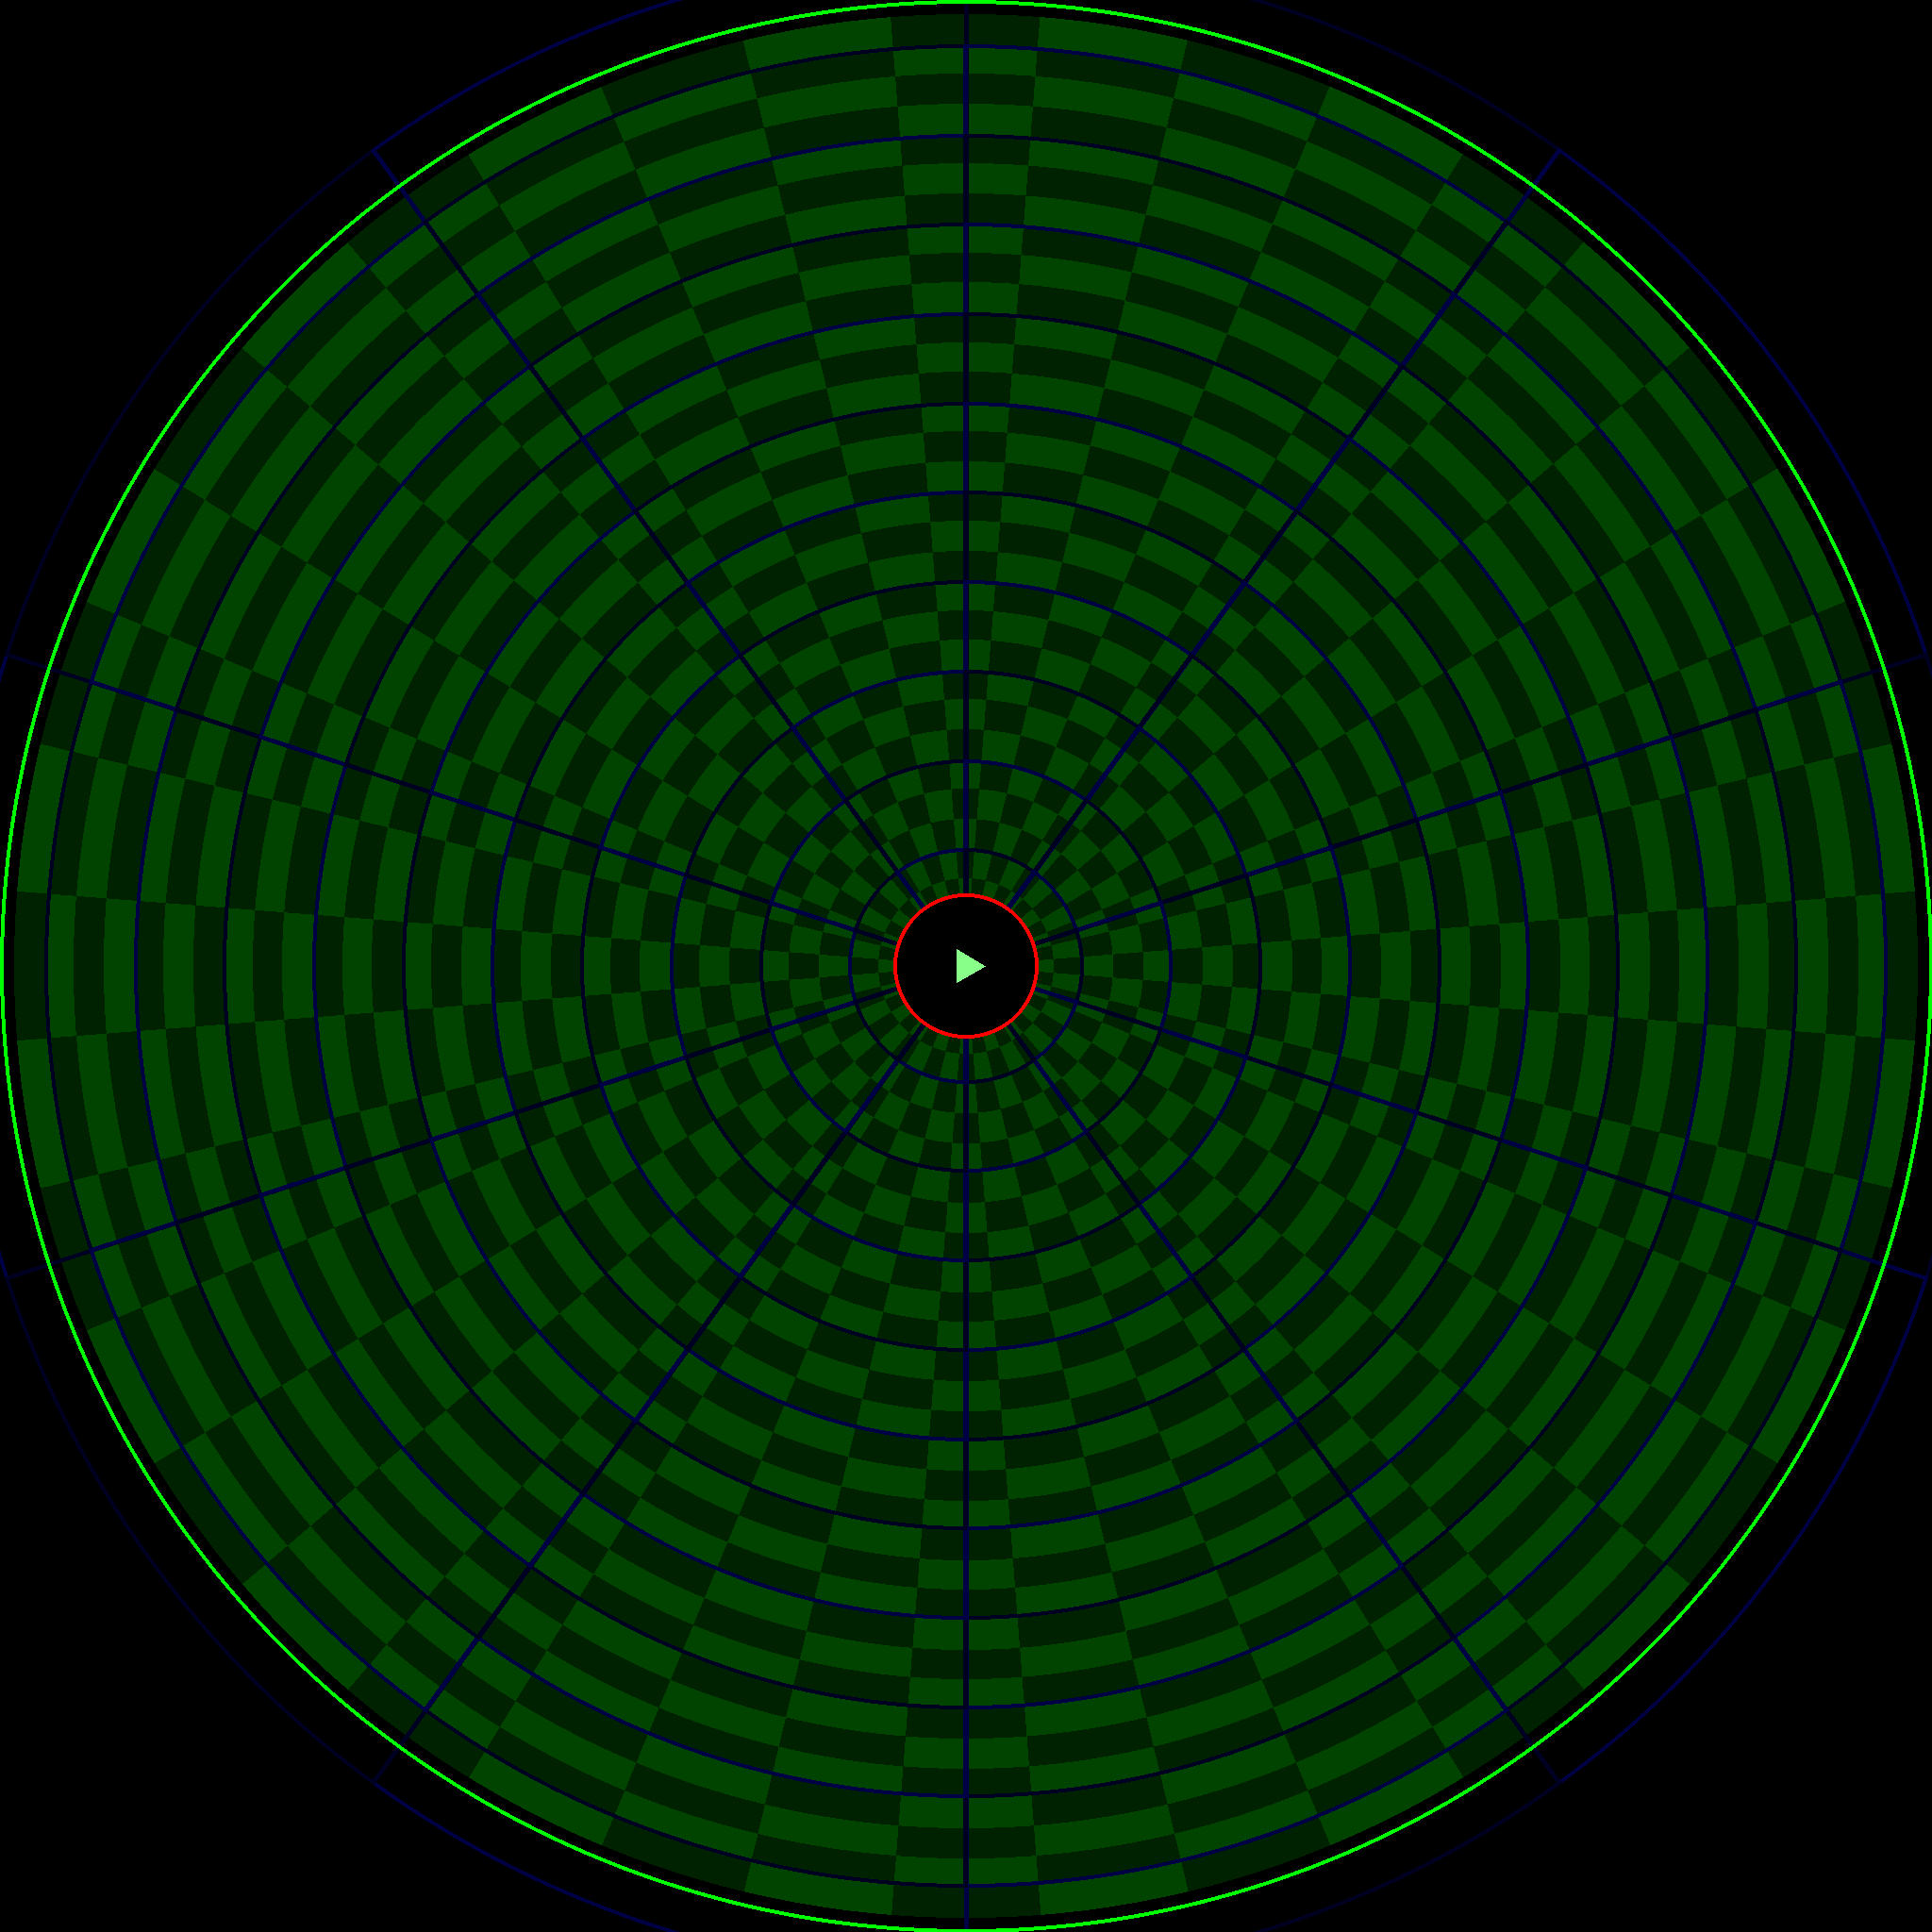

In [3]:
from stormvogel import extensions, simulator
from IPython.display import Image, display

path = simulator.simulate_path(model, 20)
a = list(model.actions)[0]
for i in path.path:
    print(i, model.transitions[path.get_state_in_step(i).id])

filename = extensions.render_model_gif(
    model,
    lambda s: s.valuations["ACAState"].draw(),
    filename="plane",
    path=path,
    fps=0.5,
)
print(filename)
display(Image(filename))